# Tarea 1 — Limpieza y análisis inicial de datos con Pandas

Este notebook conserva el dataset original y crea una copia de trabajo para aplicar las transformaciones solicitadas: eliminación de duplicados, tratamiento de valores faltantes y estandarización de formatos. También incluye tablas tipo pivote, visualizaciones y exportación del dataset depurado.

## 1. Importación y estado original

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Cargar el dataset original
df_original = pd.read_csv('dataset_sucio.csv', dtype='string')

# Copia de trabajo: el original no se modifica
df = df_original.copy()

print('Registros originales:', len(df_original))
print('Columnas:', list(df_original.columns))
df_original.head()

Registros originales: 5000
Columnas: ['id_cliente', 'nombre', 'genero', 'fecha_registro', 'gasto_q', 'ciudad', 'categoria']


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,502609,Paola Morales,m,2026-02-27,<NA>,Antigua,Retail
1,500588,ANA DIAZ,f,2026-02-24,371.80,Villa Nueva,Services
2,502408,Maria Paz,m,2026-01-15,"373,33",quetzaltenango,retail
3,501688,Ana Mejia,f,2026-01-18,361.23,Quetzaltenango,Education
4,502916,Carlos Mendez,f,29/01/2026,"339,01",Amatitlan,Retail


## 2. Valores faltantes en el estado original

In [2]:
# Convertimos cadenas vacías y espacios en valores faltantes para medirlos correctamente
df = df.replace(r'^\s*$', pd.NA, regex=True)

faltantes_original = df.isna().sum().sort_values(ascending=False)
print('Valores faltantes por columna:')
display(faltantes_original.to_frame('faltantes'))

Valores faltantes por columna:


,faltantes
gasto_q,505
ciudad,227
genero,115
nombre,0
id_cliente,0
fecha_registro,0
categoria,0


## 3. Duplicados

In [3]:
print('Registros duplicados:', df.duplicated().sum())

# Mostrar duplicados, si existen
df_duplicados = df[df.duplicated(keep=False)]
display(df_duplicados)

Registros duplicados: 100


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
33,504347,Patricia Morales,F,01/02/2026,"283,68",Quetzaltenango,SERVICES
58,503133,Carlos Solis,m,2026-01-28,"152,84",Quetzaltenango,Services
117,500028,DIANA FUENTES,F,2026-01-17,<NA>,Quetzaltenango,Services
151,500347,Gustavo Lopez,m,2026-02-04,477.55,guatemala,FOOD
191,500642,Sofia Mejia,f,2026-01-05,"3,16",Antigua,Food
...,...,...,...,...,...,...,...
4925,500631,Karla Vargas,<NA>,2026-02-13,"38,59",Amatitlan,Retail
4958,503570,Rene Hernandez,F,2026-02-12,221.16,Escuintla,Services
4970,501455,Pedro Flores,m,03/01/2026,<NA>,Quetzaltenango,Food
4982,502553,MIGUEL MOLINA,f,2026-01-22,96.49,Antigua,Retail


In [4]:
# Eliminar registros duplicados completos
registros_antes = len(df)
df = df.drop_duplicates().copy()
registros_eliminados = registros_antes - len(df)

print('Duplicados eliminados:', registros_eliminados)
print('Registros después de eliminar duplicados:', len(df))
print('Duplicados restantes:', df.duplicated().sum())

Duplicados eliminados: 100
Registros después de eliminar duplicados: 4900
Duplicados restantes: 0


## 4. Estandarización de nombres y texto

In [5]:
# Eliminar espacios innecesarios en todas las columnas de texto
columnas_texto = ['nombre', 'genero', 'ciudad', 'categoria']

for columna in columnas_texto:
    df[columna] = df[columna].astype('string').str.strip()

# Nombres: formato consistente, conservando caracteres propios del nombre
df['nombre'] = df['nombre'].str.title()

# Género: solamente se estandariza la representación textual; no se infiere el género por el nombre
df['genero'] = df['genero'].str.upper()

# Ciudad y categoría: mismo formato de escritura
df['ciudad'] = df['ciudad'].str.title()
df['categoria'] = df['categoria'].str.title()

print('Valores de género:')
display(df['genero'].value_counts(dropna=False).to_frame('cantidad'))

print('Valores de ciudad:')
display(df['ciudad'].value_counts(dropna=False).to_frame('cantidad'))

print('Valores de categoría:')
display(df['categoria'].value_counts(dropna=False).to_frame('cantidad'))

Valores de género:


,cantidad
genero,
F,2406
M,2381
<NA>,113


Valores de ciudad:


,cantidad
ciudad,
Quetzaltenango,614
Amatitlan,609
Mixco,591
Guatemala,584
Antigua,578
Villa Nueva,577
Chimaltenango,563
Escuintla,562
<NA>,222


Valores de categoría:


,cantidad
categoria,
Food,1259
Retail,1229
Education,1211
Services,1201


## 5. Estandarización de la fecha

In [6]:
# El dataset contiene fechas en formatos YYYY-MM-DD y DD/MM/YYYY.
# format='mixed' permite procesar ambos formatos y dayfirst=True resuelve las fechas con '/'.
df['fecha_registro'] = pd.to_datetime(
    df['fecha_registro'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

print('Fechas inválidas o faltantes después de la conversión:', df['fecha_registro'].isna().sum())
display(df[['id_cliente', 'fecha_registro']].head())

Fechas inválidas o faltantes después de la conversión: 0


,id_cliente,fecha_registro
0,502609,2026-02-27
1,500588,2026-02-24
2,502408,2026-01-15
3,501688,2026-01-18
4,502916,2026-01-29


## 6. Estandarización de gasto_q en Quetzales

In [7]:
# Convertir valores vacíos a NA, eliminar espacios y cambiar coma decimal por punto
df['gasto_q'] = (
    df['gasto_q']
      .astype('string')
      .str.strip()
      .str.replace(',', '.', regex=False)
)

# Convertir la columna a tipo numérico
df['gasto_q'] = pd.to_numeric(df['gasto_q'], errors='coerce')

print('Tipo de dato de gasto_q:', df['gasto_q'].dtype)
print('Valores faltantes en gasto_q:', df['gasto_q'].isna().sum())
display(df[['id_cliente', 'gasto_q']].head())

Tipo de dato de gasto_q: Float64
Valores faltantes en gasto_q: 497


,id_cliente,gasto_q
0,502609,<NA>
1,500588,371.80
2,502408,373.33
3,501688,361.23
4,502916,339.01


## 7. Tratamiento de valores faltantes

Para no eliminar registros válidos, se utilizan criterios simples y reproducibles: la mediana para `gasto_q` y la moda para las variables categóricas. Si una columna categórica no tuviera moda, se utilizaría `Sin especificar`.

In [8]:
# Antes de imputar, registrar la cantidad de faltantes
faltantes_antes = df.isna().sum()

# gasto_q: imputación con la mediana
mediana_gasto = df['gasto_q'].median()
df['gasto_q'] = df['gasto_q'].fillna(mediana_gasto)

# Variables categóricas: imputación con la moda
for columna in ['genero', 'ciudad', 'categoria']:
    if df[columna].notna().any():
        moda = df[columna].mode(dropna=True)
        valor = moda.iloc[0] if not moda.empty else 'Sin especificar'
    else:
        valor = 'Sin especificar'
    df[columna] = df[columna].fillna(valor)

# Si hubiera fechas faltantes, se conserva NA porque no es correcto inventar una fecha de registro.

faltantes_despues = df.isna().sum()
comparacion_faltantes = pd.DataFrame({
    'Antes': faltantes_antes,
    'Después': faltantes_despues
})

display(comparacion_faltantes)

,Antes,Después
id_cliente,0,0
nombre,0,0
genero,113,0
fecha_registro,0,0
gasto_q,497,0
ciudad,222,0
categoria,0,0


## 8. DataFrame depurado

In [9]:
# Mostrar el estado final
df.head(10)

,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,502609,Paola Morales,M,2026-02-27,251.80,Antigua,Retail
1,500588,Ana Diaz,F,2026-02-24,371.80,Villa Nueva,Services
2,502408,Maria Paz,M,2026-01-15,373.33,Quetzaltenango,Retail
3,501688,Ana Mejia,F,2026-01-18,361.23,Quetzaltenango,Education
4,502916,Carlos Mendez,F,2026-01-29,339.01,Amatitlan,Retail
5,504200,Oscar Rojas,M,2026-01-09,138.22,Antigua,Retail
6,502029,Isabel Ramirez,M,2026-02-05,166.31,Villa Nueva,Services
7,501366,Pedro Herrera,M,2026-02-12,405.62,Amatitlan,Education
8,502614,Patricia Soto,F,2026-01-11,222.88,Guatemala,Retail
9,502794,Pablo Perez,M,2026-02-06,287.37,Escuintla,Retail


## 9. Comparación antes y después de la limpieza

In [10]:
resumen_calidad = pd.DataFrame({
    'Métrica': [
        'Registros',
        'Duplicados',
        'Celdas faltantes'
    ],
    'Antes': [
        len(df_original),
        df_original.duplicated().sum(),
        df_original.replace(r'^\s*$', pd.NA, regex=True).isna().sum().sum()
    ],
    'Después': [
        len(df),
        df.duplicated().sum(),
        df.isna().sum().sum()
    ]
})

display(resumen_calidad)

,Métrica,Antes,Después
0,Registros,5000,4900
1,Duplicados,100,0
2,Celdas faltantes,847,0


## 10. Tablas tipo pivote con Pandas

In [11]:
# Gasto total y promedio por ciudad
pivote_ciudad = pd.pivot_table(
    df,
    index='ciudad',
    values='gasto_q',
    aggfunc=['count', 'sum', 'mean']
)
pivote_ciudad.columns = ['Cantidad clientes', 'Gasto total (Q)', 'Gasto promedio (Q)']
display(pivote_ciudad.sort_values('Gasto total (Q)', ascending=False))

,Cantidad clientes,Gasto total (Q),Gasto promedio (Q)
ciudad,,,
Quetzaltenango,836,"212,761.23",254.50
Escuintla,562,"150,258.21",267.36
Amatitlan,609,"148,643.53",244.08
Chimaltenango,563,"148,201.43",263.24
Mixco,591,"148,109.78",250.61
Antigua,578,"141,765.70",245.27
Villa Nueva,577,"140,978.31",244.33
Guatemala,584,"140,797.74",241.09


In [12]:
# Gasto total por categoría y género
pivote_categoria_genero = pd.pivot_table(
    df,
    index='categoria',
    columns='genero',
    values='gasto_q',
    aggfunc='sum',
    fill_value=0
)
display(pivote_categoria_genero)

genero,F,M
categoria,,
Education,"153,220.79","148,358.07"
Food,"166,173.14","153,753.15"
Retail,"151,607.69","157,021.55"
Services,"153,193.35","148,188.19"


## 11. Visualizaciones

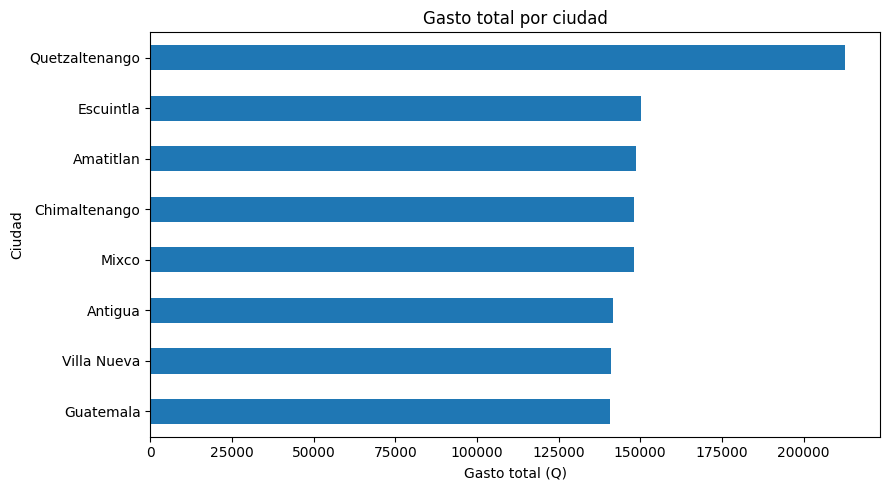

In [13]:
# Gasto total por ciudad
pivote_ciudad['Gasto total (Q)'].sort_values().plot(kind='barh', figsize=(9, 5))
plt.title('Gasto total por ciudad')
plt.xlabel('Gasto total (Q)')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

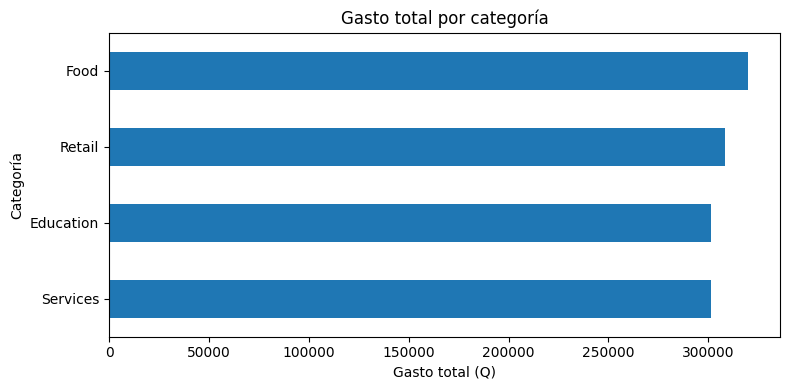

In [14]:
# Gasto total por categoría
gasto_categoria = df.groupby('categoria')['gasto_q'].sum().sort_values()
gasto_categoria.plot(kind='barh', figsize=(8, 4))
plt.title('Gasto total por categoría')
plt.xlabel('Gasto total (Q)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

## 12. Exportación del dataset limpio

In [15]:
# Exportar CSV depurado
df_export = df.copy()
df_export['fecha_registro'] = df_export['fecha_registro'].dt.strftime('%Y-%m-%d')
df_export['gasto_q'] = df_export['gasto_q'].round(2)
df_export.to_csv('dataset_limpio.csv', index=False, encoding='utf-8')

print('Archivo generado: dataset_limpio.csv')
print('Registros exportados:', len(df_export))
display(df_export.head())

Archivo generado: dataset_limpio.csv
Registros exportados: 4900


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,502609,Paola Morales,M,2026-02-27,251.80,Antigua,Retail
1,500588,Ana Diaz,F,2026-02-24,371.80,Villa Nueva,Services
2,502408,Maria Paz,M,2026-01-15,373.33,Quetzaltenango,Retail
3,501688,Ana Mejia,F,2026-01-18,361.23,Quetzaltenango,Education
4,502916,Carlos Mendez,F,2026-01-29,339.01,Amatitlan,Retail


## 13. Interpretación de resultados

- El dataset original se conserva mediante `df_original` y las transformaciones se realizan sobre `df`.
- Los duplicados completos se identifican y eliminan mediante `drop_duplicates()`.
- Los valores faltantes se cuantifican antes y después de la limpieza. El gasto se completa con la mediana y las variables categóricas con la moda.
- Las fechas quedan en un formato uniforme y `gasto_q` queda como variable numérica en Quetzales.
- Las columnas de texto se normalizan para evitar diferencias causadas por espacios y uso inconsistente de mayúsculas/minúsculas.
- Las tablas pivote permiten comparar el gasto por ciudad, categoría y género, mientras que las gráficas facilitan identificar diferencias entre grupos.